ANÁLISIS DE ENTRAMADO - PROBLEMA 8-22
REACCIONES EN A:
Ax = 0 N
Ay = 11000 N
MA = -6900000 N·mm

SECCIÓN aa:
V = 1000 N
N = 0 N
M = -400000 N·mm

SECCIÓN bb:
V = -11000.0000000000 N
N = 0.0 N
M = 6900000.00000000 N·mm

Gráfico guardado


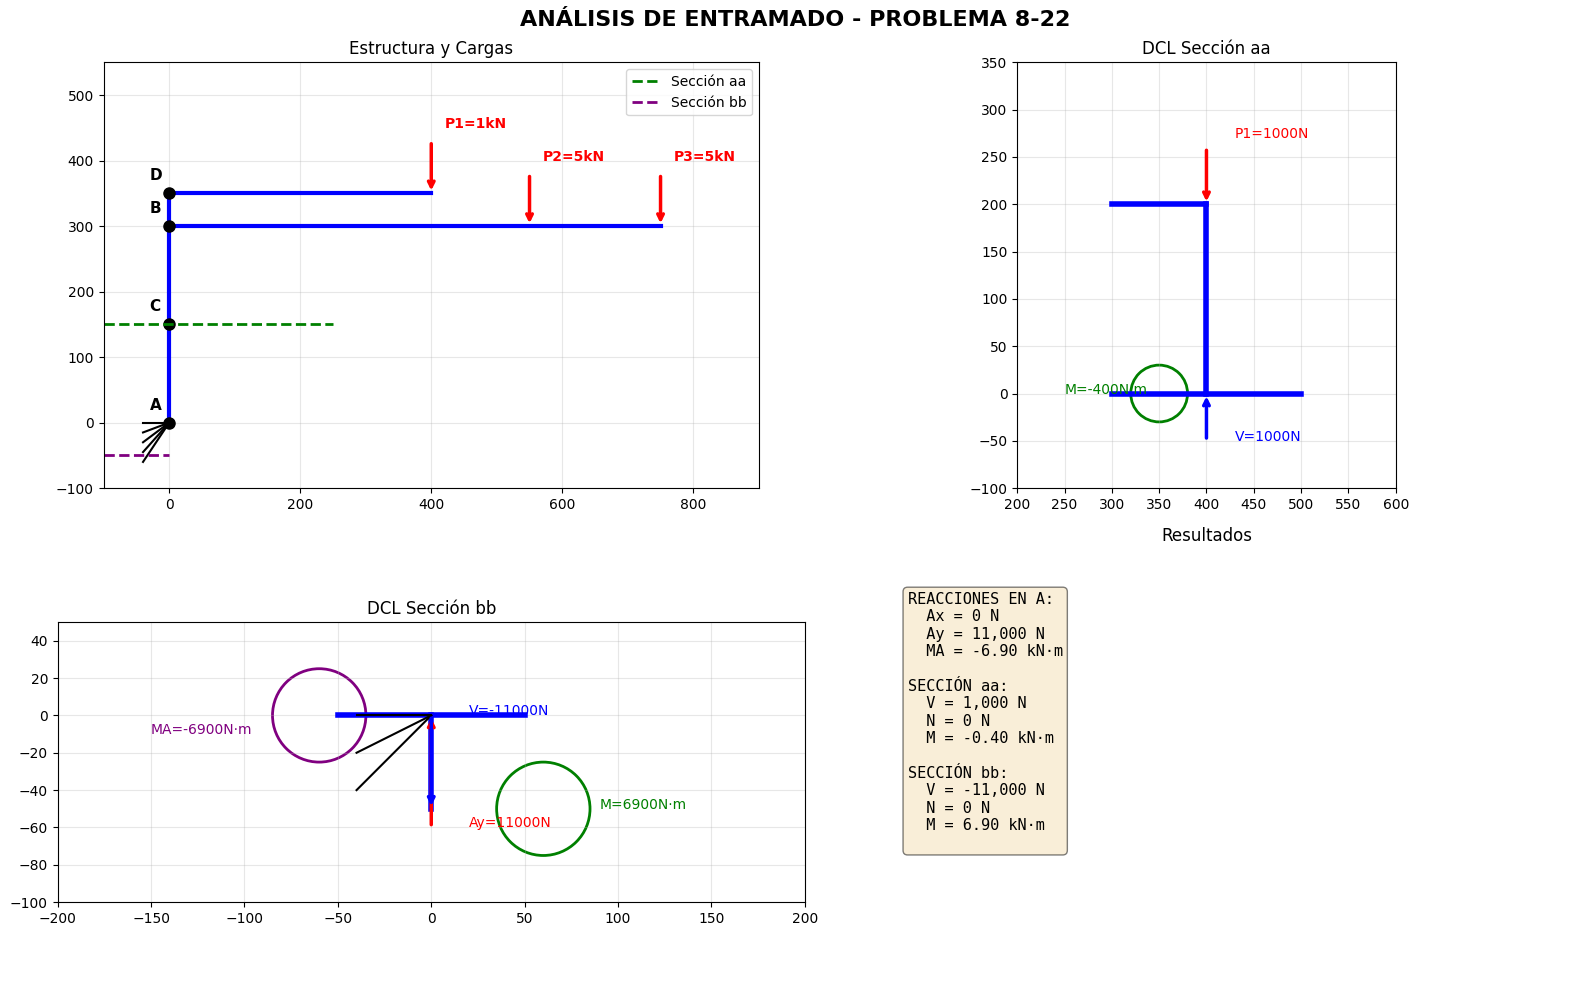

In [1]:
# ============================================================================
# ANÁLISIS DE ENTRAMADO DE TRES BARRAS - PROBLEMA 8-22
# ============================================================================

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Variables simbólicas
Ax, Ay = sp.symbols('A_x A_y', real=True)
MA = sp.symbols('M_A', real=True)
Vaa, Naa, Maa = sp.symbols('V_aa N_aa M_aa', real=True)
Vbb, Nbb, Mbb = sp.symbols('V_bb N_bb M_bb', real=True)

print("="*70)
print("ANÁLISIS DE ENTRAMADO - PROBLEMA 8-22")
print("="*70)

# Datos del problema
P1 = 1000  # N
P2 = 5000  # N
P3 = 5000  # N

h_total = 350  # mm
h_C = 150
h_B = 300

L_horiz_1 = 400
L_horiz_2 = 150
L_horiz_3 = 200

d_aa = 200
d_bb = 200

# Equilibrio global
eq1 = sp.Eq(Ax, 0)
eq2 = sp.Eq(Ay - P1 - P2 - P3, 0)

M_P1 = P1 * L_horiz_1
x_E = L_horiz_1 + L_horiz_2
M_P2 = P2 * x_E
x_F = L_horiz_1 + L_horiz_2 + L_horiz_3
M_P3 = P3 * x_F

eq3 = sp.Eq(MA + M_P1 + M_P2 + M_P3, 0)

reacciones = sp.solve([eq1, eq2, eq3], [Ax, Ay, MA])
print("REACCIONES EN A:")
print(f"Ax = {reacciones[Ax]} N")
print(f"Ay = {reacciones[Ay]} N")
print(f"MA = {reacciones[MA]} N·mm")

Ax_val = float(reacciones[Ax])
Ay_val = float(reacciones[Ay])
MA_val = float(reacciones[MA])

# Sección aa
eq_aa_1 = sp.Eq(Naa, 0)
eq_aa_2 = sp.Eq(Vaa - P1, 0)
eq_aa_3 = sp.Eq(Maa + P1 * L_horiz_1, 0)

sol_aa = sp.solve([eq_aa_1, eq_aa_2, eq_aa_3], [Vaa, Naa, Maa])
print("\nSECCIÓN aa:")
print(f"V = {sol_aa[Vaa]} N")
print(f"N = {sol_aa[Naa]} N")
print(f"M = {sol_aa[Maa]} N·mm")

Vaa_val = float(sol_aa[Vaa])
Naa_val = float(sol_aa[Naa])
Maa_val = float(sol_aa[Maa])

# Sección bb
eq_bb_1 = sp.Eq(Nbb + Ax_val, 0)
eq_bb_2 = sp.Eq(Vbb + Ay_val, 0)
eq_bb_3 = sp.Eq(Mbb + MA_val, 0)

sol_bb = sp.solve([eq_bb_1, eq_bb_2, eq_bb_3], [Vbb, Nbb, Mbb])
print("\nSECCIÓN bb:")
print(f"V = {sol_bb[Vbb]} N")
print(f"N = {sol_bb[Nbb]} N")
print(f"M = {sol_bb[Mbb]} N·mm")

Vbb_val = float(sol_bb[Vbb])
Nbb_val = float(sol_bb[Nbb])
Mbb_val = float(sol_bb[Mbb])

# Visualización
fig = plt.figure(figsize=(16, 10))
fig.suptitle('ANÁLISIS DE ENTRAMADO - PROBLEMA 8-22', fontsize=16, fontweight='bold')

# Estructura
ax1 = plt.subplot(2, 2, 1)
ax1.set_title('Estructura y Cargas')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')

ax1.plot([0, 0], [0, h_total], 'b-', linewidth=3)
ax1.plot([0, L_horiz_1], [h_total, h_total], 'b-', linewidth=3)
total_width = L_horiz_1 + L_horiz_2 + L_horiz_3
ax1.plot([0, total_width], [h_B, h_B], 'b-', linewidth=3)

points = {'A': (0, 0), 'B': (0, h_B), 'C': (0, h_C), 'D': (0, h_total)}
for name, (x, y) in points.items():
    ax1.plot(x, y, 'ko', markersize=8)
    ax1.text(x-30, y+20, name, fontsize=11, fontweight='bold')

for i in range(5):
    y_pos = -60 + i * 15
    ax1.plot([-40, 0], [y_pos, 0], 'k-', linewidth=1.5)

arrow_props = dict(arrowstyle='->', lw=2.5, color='red')
ax1.annotate('', xy=(L_horiz_1, h_total), xytext=(L_horiz_1, h_total + 80), arrowprops=arrow_props)
ax1.text(L_horiz_1 + 20, h_total + 100, 'P1=1kN', fontsize=10, color='red', fontweight='bold')

ax1.annotate('', xy=(L_horiz_1 + L_horiz_2, h_B), xytext=(L_horiz_1 + L_horiz_2, h_B + 80), arrowprops=arrow_props)
ax1.text(L_horiz_1 + L_horiz_2 + 20, h_B + 100, 'P2=5kN', fontsize=10, color='red', fontweight='bold')

ax1.annotate('', xy=(total_width, h_B), xytext=(total_width, h_B + 80), arrowprops=arrow_props)
ax1.text(total_width + 20, h_B + 100, 'P3=5kN', fontsize=10, color='red', fontweight='bold')

ax1.axhline(y=h_total - d_aa, xmin=0, xmax=0.35, color='green', linestyle='--', linewidth=2, label='Sección aa')
ax1.axhline(y=h_C - d_bb, xmin=0, xmax=0.1, color='purple', linestyle='--', linewidth=2, label='Sección bb')

ax1.legend(loc='upper right')
ax1.set_xlim(-100, total_width + 150)
ax1.set_ylim(-100, h_total + 200)

# DCL Sección aa
ax2 = plt.subplot(2, 2, 2)
ax2.set_title('DCL Sección aa')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

sec_height = h_total - (h_total - d_aa)
ax2.plot([L_horiz_1-100, L_horiz_1+100], [0, 0], 'b-', linewidth=4)
ax2.plot([L_horiz_1, L_horiz_1], [0, sec_height], 'b-', linewidth=4)
ax2.plot([L_horiz_1-100, L_horiz_1], [sec_height, sec_height], 'b-', linewidth=4)

ax2.annotate('', xy=(L_horiz_1, sec_height), xytext=(L_horiz_1, sec_height + 60), arrowprops=dict(arrowstyle='->', lw=2.5, color='red'))
ax2.text(L_horiz_1 + 30, sec_height + 70, f'P1={P1}N', fontsize=10, color='red')

ax2.annotate('', xy=(L_horiz_1, 0), xytext=(L_horiz_1, -50), arrowprops=dict(arrowstyle='->', lw=2.5, color='blue'))
ax2.text(L_horiz_1 + 30, -50, f'V={Vaa_val:.0f}N', fontsize=10, color='blue')

circle = Circle((L_horiz_1-50, 0), 30, fill=False, color='green', linewidth=2)
ax2.add_patch(circle)
ax2.text(L_horiz_1-150, 0, f'M={Maa_val/1000:.0f}N·m', fontsize=10, color='green')

ax2.set_xlim(L_horiz_1-200, L_horiz_1+200)
ax2.set_ylim(-100, sec_height + 150)

# DCL Sección bb
ax3 = plt.subplot(2, 2, 3)
ax3.set_title('DCL Sección bb')
ax3.grid(True, alpha=0.3)
ax3.set_aspect('equal')

sec_bb_height = h_C - d_bb
ax3.plot([-50, 50], [0, 0], 'b-', linewidth=4)
ax3.plot([0, 0], [0, sec_bb_height], 'b-', linewidth=4)

for i in range(3):
    y_pos = -40 + i * 20
    ax3.plot([-40, 0], [y_pos, 0], 'k-', linewidth=1.5)

ax3.annotate('', xy=(0, 0), xytext=(0, -60), arrowprops=dict(arrowstyle='->', lw=2.5, color='red'))
ax3.text(20, -60, f'Ay={Ay_val:.0f}N', fontsize=10, color='red')

circle = Circle((-60, 0), 25, fill=False, color='purple', linewidth=2)
ax3.add_patch(circle)
ax3.text(-150, -10, f'MA={MA_val/1000:.0f}N·m', fontsize=10, color='purple')

ax3.annotate('', xy=(0, sec_bb_height), xytext=(0, sec_bb_height + 50), arrowprops=dict(arrowstyle='->', lw=2.5, color='blue'))
ax3.text(20, sec_bb_height + 50, f'V={Vbb_val:.0f}N', fontsize=10, color='blue')

circle2 = Circle((60, sec_bb_height), 25, fill=False, color='green', linewidth=2)
ax3.add_patch(circle2)
ax3.text(90, sec_bb_height, f'M={Mbb_val/1000:.0f}N·m', fontsize=10, color='green')

ax3.set_xlim(-200, 200)
ax3.set_ylim(-100, sec_bb_height + 100)

# Resultados
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')
ax4.set_title('Resultados')

texto = f"""REACCIONES EN A:
  Ax = {Ax_val:,.0f} N
  Ay = {Ay_val:,.0f} N  
  MA = {MA_val/1e6:,.2f} kN·m

SECCIÓN aa:
  V = {Vaa_val:,.0f} N
  N = {Naa_val:,.0f} N
  M = {Maa_val/1e6:,.2f} kN·m

SECCIÓN bb:
  V = {Vbb_val:,.0f} N
  N = {Nbb_val:,.0f} N
  M = {Mbb_val/1e6:,.2f} kN·m
"""

ax4.text(0.1, 0.9, texto, transform=ax4.transAxes, fontsize=11, 
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('analisis_entramado.png', dpi=300, bbox_inches='tight')
print("\nGráfico guardado")
plt.show()